In [7]:
# Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Retrieves data frames from files containing data in the folder hierarchy specified
def getDataFrame(directory, group, subject, trial):
  paths = [] # Stores paths for each file in the trackers directory for a given trial
  for g in os.listdir(directory): # Checks for right subject group (familiar or unfamiliar)
    if g == group:
      for s in os.listdir(os.path.join(directory, g)): # Checks for right subject
        if s == subject:
          for t in os.listdir(os.path.join(directory, g, s, 'S001', 'trackers')): # Checks for right trial
            if t[-8:-4] == trial: # Last 4 characters indicate trial --> T0XX
              paths.append(os.path.join(directory, g, s, 'S001', 'trackers', t))

  # Iterates through dataframes created from paths and concatenates into one with columns for time and relevant position data. Assumes file order is always the same across subjects.
  df = pd.concat([pd.read_csv(path) for path in paths], axis = 1)
  df = df.loc[:, ~df.columns.duplicated()].filter(items = ['time', 'pos_x', 'pos_z', 'current_track_piece']) # Removes duplicate columns from data frame

  return df
# Retrieves cost matrix from a distance matrix- Function from DTW blog post
def getCostMatrix(dist_mat):
    """
    Find minimum-cost path through matrix `dist_mat` using dynamic programming.

    The cost of a path is defined as the sum of the matrix entries on that
    path. See the following for details of the algorithm:

    - http://en.wikipedia.org/wiki/Dynamic_time_warping
    - https://www.ee.columbia.edu/~dpwe/resources/matlab/dtw/dp.m

    The notation in the first reference was followed, while Dan Ellis's code
    (second reference) was used to check for correctness. Returns a list of
    path indices and the cost matrix.
    """

    N, M = dist_mat.shape

    # Initialize the cost matrix
    cost_mat = np.zeros((N + 1, M + 1))
    for i in range(1, N + 1):
        cost_mat[i, 0] = np.inf
    for i in range(1, M + 1):
        cost_mat[0, i] = np.inf

    # Fill the cost matrix while keeping traceback information
    traceback_mat = np.zeros((N, M))
    for i in range(N):
        for j in range(M):
            penalty = [
                cost_mat[i, j],      # match (0)
                cost_mat[i, j + 1],  # insertion (1)
                cost_mat[i + 1, j]]  # deletion (2)
            i_penalty = np.argmin(penalty)
            cost_mat[i + 1, j + 1] = dist_mat[i, j] + penalty[i_penalty]
            traceback_mat[i, j] = i_penalty

    # Traceback from bottom right
    i = N - 1
    j = M - 1
    path = [(i, j)]
    while i > 0 or j > 0:
        tb_type = traceback_mat[i, j]
        if tb_type == 0:
            # Match
            i = i - 1
            j = j - 1
        elif tb_type == 1:
            # Insertion
            i = i - 1
        elif tb_type == 2:
            # Deletion
            j = j - 1
        path.append((i, j))

    # Strip infinity edges from cost_mat before returning
    cost_mat = cost_mat[1:, 1:]
    return (path[::-1], cost_mat) # Return cost_mat and path

# Change subject lists as more data accumumlates
familiar = ['slab-0ffc1690-8485-4b06-b4b9-044095f08c61']
unfamiliar = ['guy-e15b433c-4fb9-4f27-a488-863356fbcb53']
track_pieces = ['chicane','triple_s', 'symmetric_parabolic', 'traffic_circle', 'asymmetric_parabolic_2', 't_turn', 'asymmetric_parabolic_1', 'spiral'] # 8 track segments in T010 and T011 not including straight pieces
average_costs = []

# Assigns raw string directory path
# data_dp = r'C:/Users/graci/Dropbox/PAndA/Thesis Experiment 2/data/pilot_data' # data directory path (data_dp) will vary depending on machine.
# Requests user input
data_dp = input('Enter data directory path: ')
while os.path.exists(data_dp) != True:
  data_dp = input('Path not found. Enter data directory path: ')

Enter data directory path: /content/drive/MyDrive/URP (Spring 2025)/pilot_data


In [8]:
for group in [familiar, unfamiliar]: # Iterates through familiar and unfamiliar lists

  group_cost = 0
  for subject in group: # Iterates through the subjects contained in the familiar and unfamiliar list variables

    # Accesses subject data and combine all the subjects files into a data frame
    T010 = getDataFrame(data_dp, 'familiar' if subject in familiar else 'unfamiliar', subject, 'T010')
    T011 = getDataFrame(data_dp, 'familiar' if subject in familiar else 'unfamiliar', subject, 'T011')


    # Change RESET to corresponding track piece in T011
    reset_indices = list(T011[T011['current_track_piece'] == 'RESET'].index) # Gets indices of data frame containing 'RESET'

    count = 0 # Switches track piece when break in consecutive instances of 'RESET' elements occurs
    for i in range(len(reset_indices) - 1):
      if reset_indices[i] == reset_indices[i + 1] - 1: # Checks if reset_indices are consecutive
        T011.at[reset_indices[i], 'current_track_piece'] = track_pieces[count] # Can be shortened to just if statement with inverse condition and assignment above if and below for
      else:
        T011.at[reset_indices[i], 'current_track_piece'] = track_pieces[count]
        count += 1


    subject_cost = 0
    for piece in track_pieces: # Iterates through the pieces in the track_pieces list variable
      # Finds euclidean distance matrix between trajectories for subject on T010 and T011 on a given piece
      trajectory_1 = T010[T010['current_track_piece'] == piece][['pos_x', 'pos_z']].values
      trajectory_2 = T011[T011['current_track_piece'] == piece][['pos_x', 'pos_z']].values
      dist_matrix = cdist(trajectory_1, trajectory_2, 'euclidean')

      # Gets cost matrix and DTW path that corresponds to distance matrix
      path, cost_matrix = getCostMatrix(dist_matrix)

      # Normalizes cost using matrix dimension sum method with the top right most entry in the matrix being the final cost value
      # which is divided by the sum of the matrix dimensions
      norm_cost = cost_matrix[cost_matrix.shape[0] - 1][cost_matrix.shape[1] - 1] / (cost_matrix.shape[0] * cost_matrix.shape[1])

      # Sums subjects norm cost for overall cost once every piece norm_cost is calculated
      subject_cost += norm_cost

    # Sums average cost of each subject for overall group cost
    group_cost += subject_cost/len(track_pieces)

  # Appends average cost of group to average_costs in the order of familiar and unfamiliar
  average_costs.append(group_cost/len(group))

print(average_costs)

[0.45110077167632356, 0.45645049933082293]


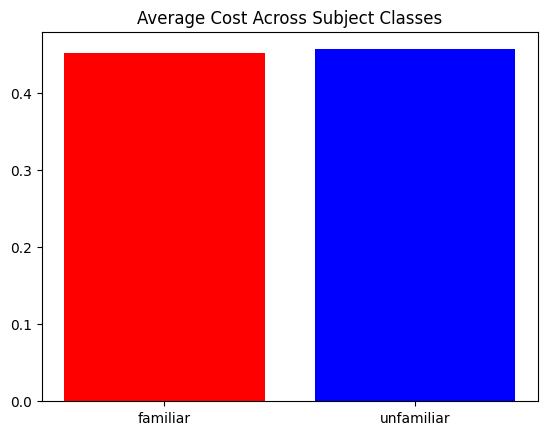

In [9]:
# Bar plot of average costs for each group
plt.bar(['familiar', 'unfamiliar'], average_costs, color = ['red', 'blue'])
plt.title('Average Cost Across Subject Classes')
plt.show()